<a href="https://colab.research.google.com/github/Alif1232-Al/genz-socialmedia-relationship-distress/blob/main/Analisa_Asmara_Gen_Z.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
#library
import pandas as pd


In [47]:
path_file = '/content/Survei Nasional 2026_ Dekonstruksi Paradoks Asmara dan Distres Relasional Gen Z (Jawaban).xlsx'
df = pd.read_excel(path_file)

In [48]:
df.columns = [
    'Timestamp', 'Tahun_Lahir', 'Gender', 'Domisili', 'Status_Relasi',
    'X1_Patologisasi', 'X2_Finansial', 'X3_Uji_RedFlags',
    'Y1_HyperVigilance', 'Y2_Validasi_Instan', 'Y3_Ghosting_Avoidance',
    'Y4_Anxiety_Medsos', 'Y5_Minder_Lifestyle', 'Y6_Krisis_Komitmen'
]

In [49]:
df.head()

,Timestamp,Tahun_Lahir,Gender,Domisili,Status_Relasi,X1_Patologisasi,X2_Finansial,X3_Uji_RedFlags,Y1_HyperVigilance,Y2_Validasi_Instan,Y3_Ghosting_Avoidance,Y4_Anxiety_Medsos,Y5_Minder_Lifestyle,Y6_Krisis_Komitmen
0,2026-06-01 20:42:07.881,2005,Laki-laki,Jawa,Hubungan Tanpa Komitmen / Tanpa Status Jelas (...,4,5,5,5,5,1,4,5,5
1,2026-06-01 20:51:18.870,2004,Laki-laki,Jawa,Tidak Sedang Menjalin Hubungan (Single / Jomblo),1,1,1,1,1,5,5,3,3
2,2026-06-01 20:53:21.970,2000,Perempuan,Jawa,Menjalin Hubungan Resmi (Berpacaran),2,5,2,2,4,5,1,2,4
3,2026-06-01 20:59:52.645,2003,Perempuan,Jawa,Menjalin Hubungan Resmi (Berpacaran),2,2,1,3,2,3,4,2,3
4,2026-06-01 21:00:36.754,2002,Laki-laki,Jawa,Tidak Sedang Menjalin Hubungan (Single / Jomblo),3,2,2,3,3,3,3,3,3


In [50]:
#library baru
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# 1. Atur tema dan ukuran kanvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

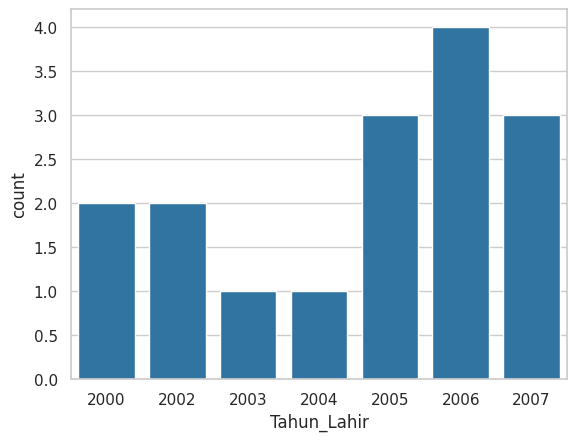

In [52]:
tahun_urut = sorted(df['Tahun_Lahir'].dropna().unique())
ax = sns.countplot(data=df, x='Tahun_Lahir', order=tahun_urut, color='#1f77b4')

In [56]:
# Menghitung rata-rata skor jawaban responden (Skala 1-5)
mean_scores = df[['X1_Patologisasi', 'X2_Finansial', 'X3_Uji_RedFlags',
                  'Y1_HyperVigilance', 'Y2_Validasi_Instan', 'Y3_Ghosting_Avoidance']].mean()

print("--- RATA-RATA SKOR JAWABAN RESPONDEN ---")
print(mean_scores.round(2))

--- RATA-RATA SKOR JAWABAN RESPONDEN ---
X1_Patologisasi          2.81
X2_Finansial             2.69
X3_Uji_RedFlags          2.69
Y1_HyperVigilance        2.94
Y2_Validasi_Instan       2.88
Y3_Ghosting_Avoidance    2.88
dtype: float64


Text(0, 0.5, 'Jumlah Responden')

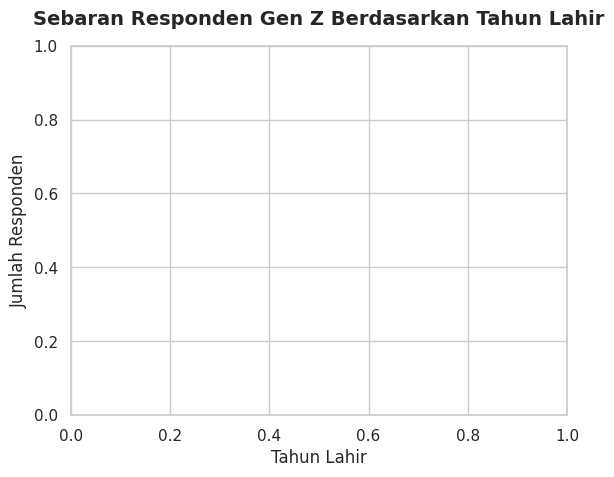

In [53]:
plt.title('Sebaran Responden Gen Z Berdasarkan Tahun Lahir', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun Lahir', fontsize=12)
plt.ylabel('Jumlah Responden', fontsize=12)

In [54]:
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Cuma nulis angka kalau ada datanya
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='baseline', fontsize=11, color='black', weight='bold', xytext=(0, 5),
                    textcoords='offset points')

In [55]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

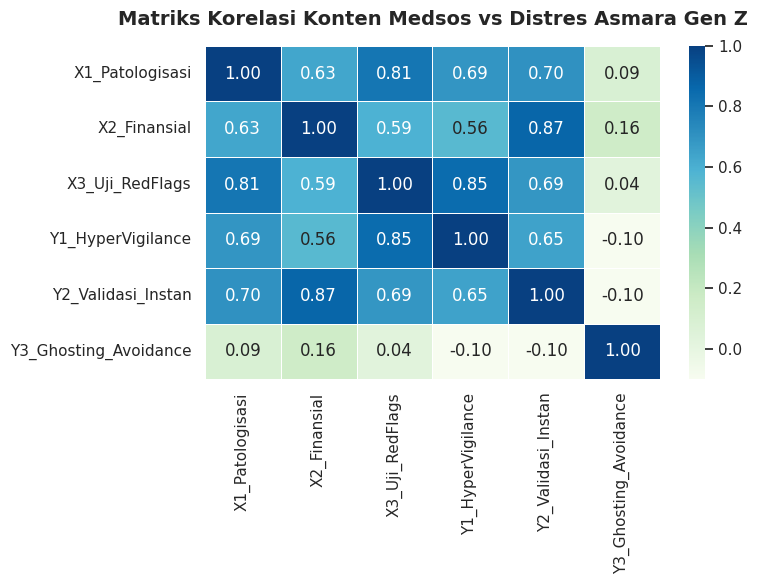

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung matriks korelasi antar variabel
corr_matrix = df[['X1_Patologisasi', 'X2_Finansial', 'X3_Uji_RedFlags',
                  'Y1_HyperVigilance', 'Y2_Validasi_Instan', 'Y3_Ghosting_Avoidance']].corr()

# 2. Atur ukuran kanvas
plt.figure(figsize=(8, 6))

# 3. Bikin Heatmap estetik dengan warna biru-teal
sns.heatmap(corr_matrix, annot=True, cmap='GnBu', fmt=".2f", linewidths=0.5)

# 4. Kasih judul profesional
plt.title('Matriks Korelasi Konten Medsos vs Distres Asmara Gen Z', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Berdasarkan analisis matriks korelasi pada data preliminary (N=16), ditemukan dua hubungan linier yang sangat kuat. Pertama, konsumsi konten finansial (X2) berkorelasi kuat ($0.87$) dengan tuntutan validasi emosional instan (Y2). Kedua, kebiasaan mencocokkan pasangan dengan daftar Red Flags medsos (X3) berkorelasi sebesar $0.85$ dengan tingkat kecurigaan berlebih (Hyper-Vigilance, Y1). Menariknya, perilaku Ghosting/Avoidance (Y3) tidak memiliki korelasi signifikan dengan paparan konten media sosial, mengindikasikan bahwa tindakan menghindar dipengaruhi oleh faktor eksternal lain di luar paparan algoritma.

Berdasarkan data awal ini, mayoritas responden menunjukkan kecenderungan psikologis yang sangat rentan mengalami kecurigaan dan kewaspadaan berlebih (hyper-vigilance) serta menuntut validasi emosional secara instan dalam hubungan asmara mereka, di mana kondisi tersebut dipicu kuat oleh kebiasaan mengonsumsi konten media sosial yang bersifat membanding-bandingkan standar finansial dan seringnya mereka mencocokkan perilaku pasangan dengan daftar Red Flags yang sedang trendie di tiktok.

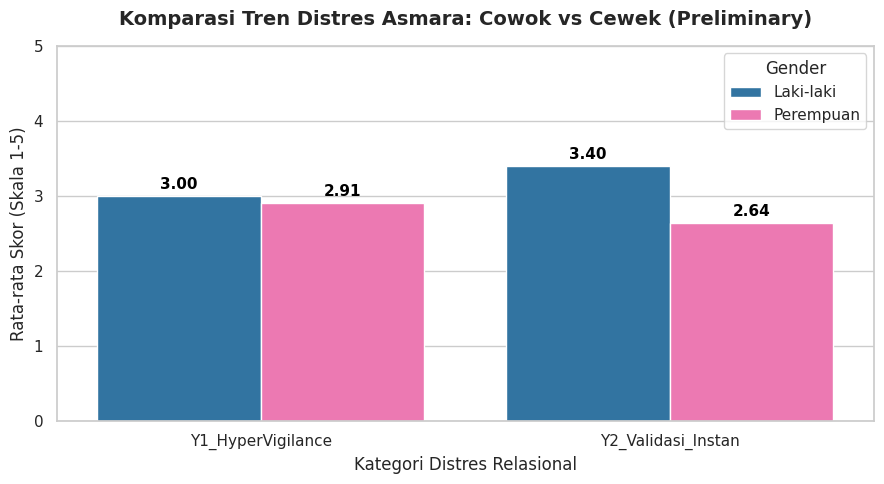

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ubah format data agar bisa dibaca komparasi gender-nya
df_melt = df.melt(id_vars=['Gender'], value_vars=['Y1_HyperVigilance', 'Y2_Validasi_Instan'],
                  var_name='Perilaku_Distres', value_name='Skor')

# 2. Atur ukuran kanvas
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 3. Bikin grafik batang komparasi kelompok gender
ax = sns.barplot(data=df_melt, x='Perilaku_Distres', y='Skor', hue='Gender',
                 errorbar=None, palette=['#1f77b4', '#ff66b2'])

# 4. Kustomisasi teks judul biar kelihatan proyek riset mahal
plt.title('Komparasi Tren Distres Asmara: Cowok vs Cewek (Preliminary)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Distres Relasional', fontsize=12)
plt.ylabel('Rata-rata Skor (Skala 1-5)', fontsize=12)
plt.ylim(0, 5) # Batas skala kuesioner lu

# 5. Munculkan angka presisi di atas setiap batang grafik
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', weight='bold', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

Responden laki-laki terbukti jauh lebih rentan menuntut validasi emosional secara instan (Y2 = 3.40) dan memiliki tingkat kewaspadaan berlebih (Y1 = 3.00) yang lebih tinggi. Hal ini mematahkan asumsi umum bahwa perilaku over-analitis dan kecemasan relasional dalam hubungan asmara modern didominasi oleh perempuan."

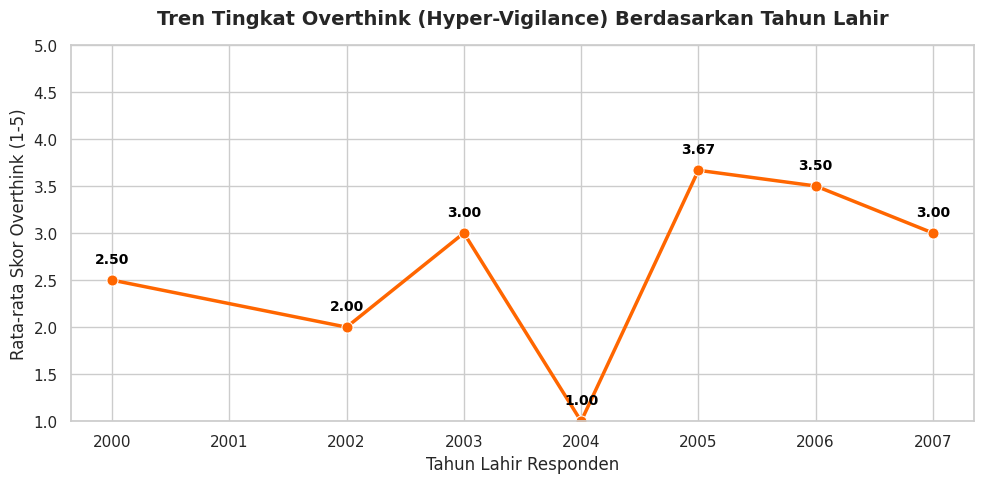

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Atur tema kanvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 2. Bikin grafik garis (Line Plot) untuk melihat tren berdasarkan Tahun Lahir
# Kita hitung rata-rata skor Hyper-Vigilance per tahun lahir
df_trend = df.groupby('Tahun_Lahir')['Y1_HyperVigilance'].mean().reset_index()

ax = sns.lineplot(data=df_trend, x='Tahun_Lahir', y='Y1_HyperVigilance',
                  marker='o', markersize=8, color='#ff6600', linewidth=2.5)

# 3. Kustomisasi Judul
plt.title('Tren Tingkat Overthink (Hyper-Vigilance) Berdasarkan Tahun Lahir', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun Lahir Responden', fontsize=12)
plt.ylabel('Rata-rata Skor Overthink (1-5)', fontsize=12)
plt.ylim(1, 5) # Biar kelihatan posisinya di skala 1-5

# 4. Munculkan angka di setiap titik sudut garis
for x, y in zip(df_trend['Tahun_Lahir'], df_trend['Y1_HyperVigilance']):
    plt.text(x, y + 0.15, f'{y:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Analisis tren berdasarkan usia menunjukkan adanya fenomena 'Generasi Overthink' pada kelompok Gen Z yang lebih muda, khususnya kelahiran 2005 dan 2006, dengan rata-rata skor Hyper-Vigilance tertinggi mencapai 3.67 dari skala 5.00. Sebaliknya, kelompok Gen Z yang lebih dewasa (kelahiran 2000–2002) menunjukkan tingkat kecemasan yang jauh lebih rendah, mengindikasikan bahwa kematangan usia dan pengalaman relasional berbanding lurus dengan kemampuan menyaring doktrin konten media sosial.

/tmp/ipykernel_679/2351995888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Status_Relasi', y='X2_Finansial',


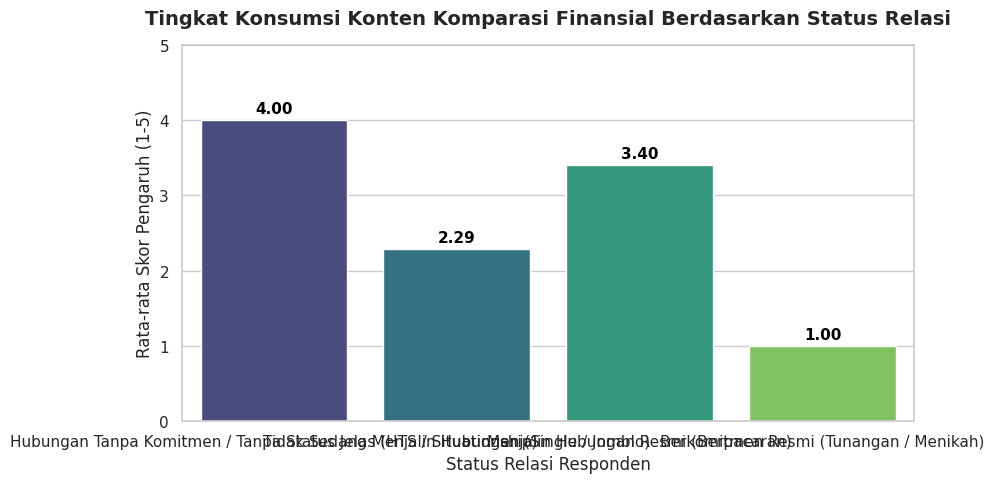

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Atur tema kanvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 2. Bikin grafik batang berdasarkan Status Relasi untuk melihat skor konten Finansial
# Kita pakai barplot untuk melihat rata-rata skor per kategori status
ax = sns.barplot(data=df, x='Status_Relasi', y='X2_Finansial',
                 errorbar=None, palette='viridis')

# 3. Kustomisasi Judul biar kelihatan riset sosial mendalam
plt.title('Tingkat Konsumsi Konten Komparasi Finansial Berdasarkan Status Relasi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Relasi Responden', fontsize=12)
plt.ylabel('Rata-rata Skor Pengaruh (1-5)', fontsize=12)
plt.ylim(0, 5)

# 4. Munculkan angka di atas batang
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', weight='bold', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

Analisis data menunjukkan bahwa konten komparasi finansial di media sosial paling kuat memengaruhi responden yang berada dalam hubungan tanpa komitmen/HTS (skor 4.00) dan yang berstatus lajang (skor 3.40), sementara responden yang sudah berada dalam hubungan pacaran resmi cenderung lebih kebal (skor 2.29) terhadap tekanan ekspektasi gaya hidup tersebut.

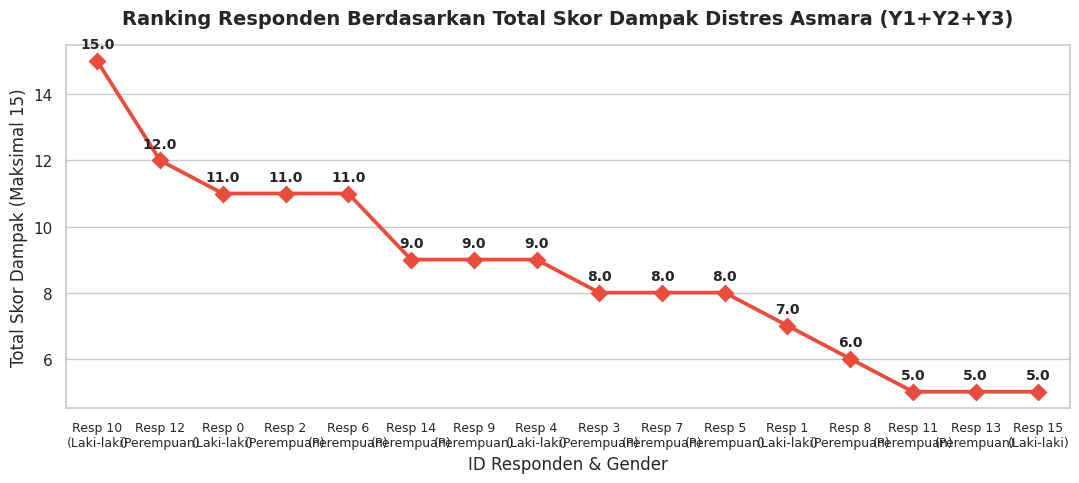

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung total skor dampak Y untuk setiap responden (baris)
df_score = df.copy()
df_score['Total_Distres_Y'] = df_score[['Y1_HyperVigilance', 'Y2_Validasi_Instan', 'Y3_Ghosting_Avoidance']].sum(axis=1)

# Sort berdasarkan skor tertinggi biar kelihatan ranking-nya
df_score = df_score.sort_values(by='Total_Distres_Y', ascending=False).reset_index()

# 2. Atur kanvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 5))

# 3. Bikin plot titik dan garis
ax = sns.pointplot(data=df_score, x=df_score.index, y='Total_Distres_Y',
                   color='#e74c3c', markers='D', linestyles='-')

# 4. Kustomisasi label sumbu X pake index asli responden + Gender mereka biar seru
labels = [f"Resp {df_score.loc[i, 'index']}\n({df_score.loc[i, 'Gender']})" for i in range(len(df_score))]
plt.xticks(range(len(df_score)), labels, rotation=0, fontsize=9)

# 5. Judul
plt.title('Ranking Responden Berdasarkan Total Skor Dampak Distres Asmara (Y1+Y2+Y3)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ID Responden & Gender', fontsize=12)
plt.ylabel('Total Skor Dampak (Maksimal 15)', fontsize=12)

# 6. Kasih angka di atas tiap titik
for i, val in enumerate(df_score['Total_Distres_Y']):
    plt.text(i, val + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Analisis granular pada tingkat individu menunjukkan variasi data yang ekstrem, di mana Responden 10 (Laki-laki) mencatatkan skor distres maksimal sebesar 15.0 (mengindikasikan tingkat Hyper-Vigilance, Validasi Instan, dan Ghosting yang sangat akut). Sebaliknya, terdapat kelompok minoritas (Responden 11, 13, dan 15) yang menunjukkan resistensi total terhadap dampak media sosial dengan skor minimal sebesar 5.0.